In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [34]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [2]:
#DOMAIN SUBSETTING
############################################################
ocean_percent=2/8

left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
end_xh=len(data['xh'])-1-50
end_xf=len(data['xf'])-1-50

print(f'x in {0}:{where_coast_xh-1} FOR SEA')
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# t_end=78 
# if res=='250m':t_end=410
# print(f't in {0}:{t_end} (6.5 hours)')
t_start=36 
print(f't in {t_start}:end (8 hours)')


#SUBSETTING CODE
#[OCEAN=data.isel(time=slice(0,78+1),xh=slice(0,where_coast_xh+1),xf=slice(0,where_coast_xf+1))]
# data=data.isel(time=slice(0,78+1),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1))
# # parcel=parcel.isel(time=slice(0,78+1))
data=data.isel(time=slice(t_start,None),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1))

x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)


In [ ]:
##########################################################################################
#Functions
# Full Profile function makes profile together for all timesteps. AveragedProfiles funciton takes the final mean of the combined profile.

In [5]:
def call_variables(t): #***
    if np.mod(t,25)==0: print(f'loading variables for time {t}')
    # variable='w'; w_data=data[variable].isel(time=t).interp(zf=data['zh']).data #get w_data and interpolation w data z coordinate from zh to zf
    variable='winterp'; w_data=data[variable].isel(time=t).data
    variable='qv'; qv_data=data[variable].isel(time=t).data # get qc data
    variable='qc'; qc_data=data[variable].isel(time=t).data # get qc data
    variable='qi'; qi_data=data[variable].isel(time=t).data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].isel(time=t).data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].isel(time=t).data # get qc data
    
    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}_{Np_str}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][t]
    
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{Np_str}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        HMC_data = f['conv'][t]
        
    if np.mod(t,25)==0:print(f'done loading')
    return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data

In [6]:
#Making vertical profile of cloudy updrafts

# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     variable='th'; th_data=data[variable].data # get qc data
#     variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    
#     import h5py
#     with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
#         theta_e_data = f['theta_e'][:]
        
#     print('done loading')
#     emptylike=True

#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6
def final_profile(var,type):
        
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    Nt=len(data['time'])
    for t in np.arange(Nt):

        #call in data 
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data]=call_variables(t) #IF LOADING IN FULL VARIABLES, COMMENT OUT #***
        
        # finds regions that match the threshold
        if type=="general":
            where_updraft=np.where((w_data>=w_thresh1) & (qc_plus_qi<qcqi_thresh)) #uncomment for "general updraft"
        elif type=='cloudy': 
            where_updraft=np.where((w_data>=w_thresh2) & (qc_plus_qi>=qcqi_thresh)) #uncomment for "cloudy updraft" 
    
        #get incidies associated with threshold mask
        # t_ind, y_ind, x_ind = where_updraft #IF LOADING IN FULL VARIABLES, UNCOMMENT #***
        z_ind, y_ind, x_ind = where_updraft #IF LOADING IN FULL VARIABLES, COMMENT OUT
    
        #gets data associated with threshold mask
        if var=='w':
            masked_data=w_data[where_updraft]
        elif var=='qv':
            masked_data=qv_data[where_updraft]
        elif var=='qc':
            masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
        elif var=='qi':
            masked_data=qi_data[where_updraft]
        elif var=='th':
            masked_data=th_data[where_updraft]
        elif var=='th_e':
            masked_data=theta_e_data[where_updraft]
        elif var=='buoyancy':
            masked_data=buoyancy_data[where_updraft]
        elif var=='HMC':
            masked_data=HMC_data[where_updraft]
            
        #converts qv and qc from kg/kg=>g/kg
        if var in ['qv','qc','qi','HMC']:
            masked_data*=1000
    
        #bin masked values by z level
        for (kh,value) in zip(z_ind,masked_data):
            profile_array[kh,0]+=value #adds data to first column
            profile_array[kh,1]+=1 #adds +1 counter to 2nd column

        #deleting variables before recalling
        del w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data #IF LOADING IN FULL VARIABLES, COMMENT OUT #***
    return profile_array

In [4]:
# #Making vertical CTRL profile of cloudy updrafts

# #thresholds
# w_thresh1=0.1
# w_thresh2=0.5
# qcqi_thresh=1e-6
# def CTRL_final_profile(var,type):
#     Nt=len(data['time'])
        
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     for t in np.arange(Nt):

#         #call in data
#         [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data,HMC_data]=call_variables(t)
        
#         # finds regions that match the threshold
#         if type=="general":
#             where_updraft=np.where((w_data<w_thresh1) | (qc_plus_qi>=qcqi_thresh)) #uncomment for "general updraft"
#         elif type=='cloudy': 
#             where_updraft=np.where((w_data<w_thresh2) | (qc_plus_qi<qcqi_thresh)) #uncomment for "cloudy updraft" 
    
#         #get incidies associated with threshold mask
#         z_ind, y_ind, x_ind = where_updraft
    
#         #gets data associated with threshold mask
#         if var=='w':
#             masked_data=w_data[where_updraft]
#         elif var=='qv':
#             masked_data=qv_data[where_updraft]
#         elif var=='qc':
#             masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
#         elif var=='qi':
#             masked_data=qi_data[where_updraft]
#         elif var=='th':
#             masked_data=th_data[where_updraft]
#         elif var=='th_e':
#             masked_data=theta_e_data[where_updraft]
#         elif var=='buoyancy':
#             masked_data=buoyancy_data[where_updraft]
#         elif var=='HMC':
#             masked_data=HMC_data[where_updraft]
            
#         #converts qv and qc from kg/kg=>g/kg
#         if var in ['qv','qc','qi','HMC']:
#             masked_data*=1000
    
#         #bin masked values by z level
#         for (kh,value) in zip(z_ind,masked_data):
#             profile_array[kh,0]+=value #adds data to first column
#             profile_array[kh,1]+=1 #adds +1 counter to 2nd column

#         #deleting variables before recalling
#         del w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data
#     return profile_array

In [ ]:
##########################################################################################
#Running (Only Run Once)

In [7]:
#Final_Profile Function

yes_run=False
yes_run=True #uncomment if running

if yes_run==True: 
    res='1km' 
    # res='250m'
    
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        vars=['w','qv','qc','qi','th','th_e','buoyancy','HMC']
        # vars=['qc','th'] #TESTING***
        for var in vars:
            print(f'working on {var}')
            globals()[f"profile_{var}"]=final_profile(var,type)
        print('done')
        
        #Saving eulerian_profiles
        import h5py
        if res=='1km':
            if type == "general":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_{res}_{Np_str}.h5' 
            elif type == "cloudy":
                output_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_{res}_{Np_str}.h5'
        
        if res=='250m':
            if type == "general":
                output_file = dir+f'Project_Algorithms/plots/job_out/250m_general_eulerian_profiles_{res}_{Np_str}.h5' 
            elif type == "cloudy":
                output_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_eulerian_profiles_{res}_{Np_str}.h5' 
        
        with h5py.File(output_file, 'w') as f:
            f.create_dataset('profile_w', data=profile_w, compression="gzip")
            f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
            f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
            f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
            f.create_dataset('profile_th', data=profile_th, compression="gzip")
            f.create_dataset('profile_th_e', data=profile_th_e, compression="gzip")
            f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
            f.create_dataset('profile_HMC', data=profile_HMC, compression="gzip")

currently on type general
working on w
loading variables for time 0
done loading
loading variables for time 25
done loading
loading variables for time 50
done loading
loading variables for time 75
done loading
working on qv
loading variables for time 0
done loading
loading variables for time 25
done loading
loading variables for time 50
done loading
loading variables for time 75
done loading
working on qc
loading variables for time 0
done loading
loading variables for time 25
done loading
loading variables for time 50
done loading
loading variables for time 75
done loading
working on qi
loading variables for time 0
done loading
loading variables for time 25
done loading
loading variables for time 50
done loading
loading variables for time 75
done loading
working on th
loading variables for time 0
done loading
loading variables for time 25
done loading
loading variables for time 50
done loading
loading variables for time 75
done loading
working on th_e
loading variables for time 0
done 

In [1]:
# #CTRL_Final_Profile Function
# label=1

# yes_run=False
# yes_run=True #uncomment if running

# if yes_run==True: 
#     res='1km' 
#     # res='250m'
    
#     for type in ["general","cloudy"]:
#         print(f'currently on type {type}')
        
#         vars=['w','qv','qc','qi','th','buoyancy','HMC']
#         # vars=['qc','th'] #TESTING***
#         for var in vars:
#             print(f'working on {var}')
#             globals()[f"profile_{var}"]=CTRL_final_profile(var,type)
#         print('done')
        
#         #Saving eulerian_profiles
#         import h5py
#         if res=='1km':
#             if type == "general":
#                 output_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_{res}.h5' 
#             elif type == "cloudy":
#                 output_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_{res}.h5'
        
#         if res=='250m':
#             if type == "general":
#                 output_file = dir+f'Project_Algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_{res}.h5' 
#             elif type == "cloudy":
#                 output_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_{res}.h5' 
        
#         with h5py.File(output_file, 'w') as f:
#             f.create_dataset('profile_w', data=profile_w, compression="gzip")
#             f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
#             f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
#             f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
#             f.create_dataset('profile_th', data=profile_th, compression="gzip")
#             f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")

In [ ]:
##########################################################################################
#Plotting

In [11]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

array([-1.01351438e-04,  1.29011102e-06,  1.65955338e-06,  2.47598267e-05,
        3.60530484e-05,  8.30295329e-05,  6.97148377e-05,  3.87108176e-05,
        2.80859491e-06, -1.60720942e-05, -4.18530463e-05, -4.20332641e-05,
       -2.08529129e-05, -6.06093168e-06, -2.95392781e-06, -1.77003979e-06,
       -1.06425505e-06, -1.65773862e-06, -1.30772313e-06, -3.99746002e-07,
       -1.06473374e-07, -1.18800218e-07, -4.84812440e-09, -2.47113080e-08,
        7.92098731e-10, -1.05948316e-09,  7.21734858e-11])

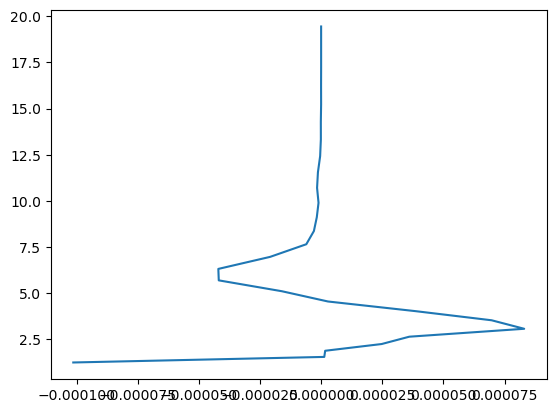

In [21]:
out=averaged_profiles('HMC')
plt.plot(out[:,0],out[:,1])

out[:,0]
apply

currently on type general
currently on type cloudy


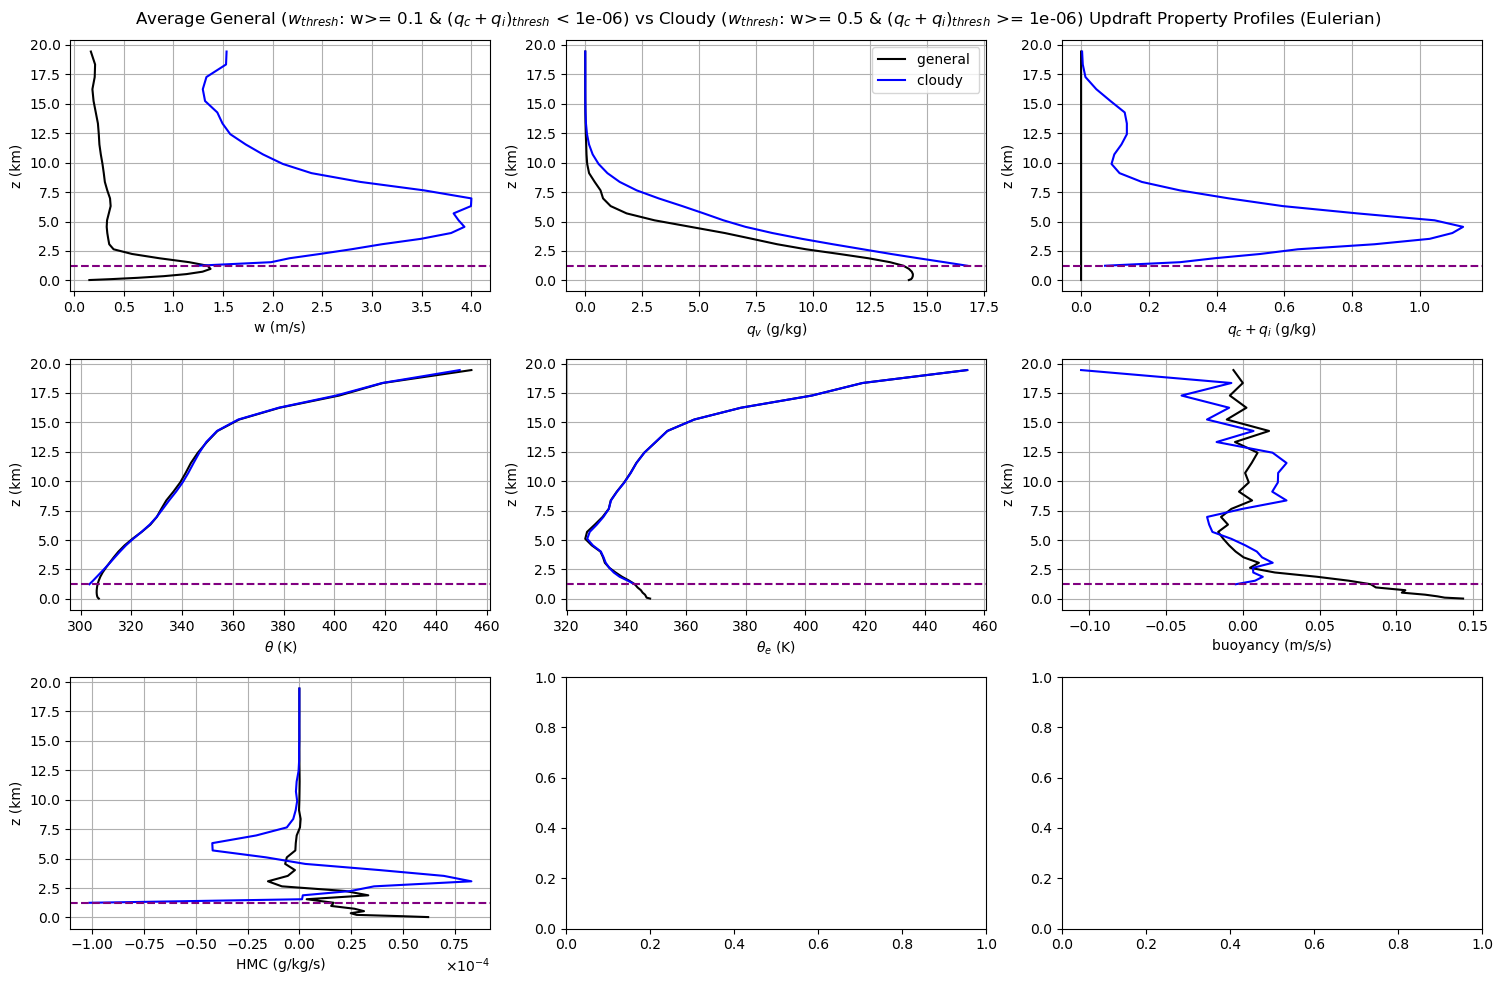

In [35]:
import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
res='1km'
# res='250m'
label=1

#Uses Plotting Function 
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
# if type=='general':
#     fig.suptitle(f"average eulerian updraft property profiles") 
# if type=='cloudy':
#     fig.suptitle(f"average eulerian cloudy updraft property profiles")
fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles (Eulerian)")
#CHANGE TITLE IF CTRL CASE IF USING
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
# plt.tight_layout()

####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')
    
    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_{res}_{Np_str}.h5'
            # input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_{res}_{Np_str}.h5' 
            # input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
    
    if res=='250m':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_eulerian_profiles_{res}_{Np_str}.h5' 
            # input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_eulerian_profiles_CTRL_{res}_{Np_str}.h5' 
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_eulerian_profiles_{res}_{Np_str}.h5' 
            # input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_eulerian_profiles_CTRL_{res}_{Np_str}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_th_e = np.array(f['profile_th_e'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
        profile_HMC = np.array(f['profile_HMC'])
    
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars=['w','qv','qc','th','th_e','buoyancy', 'HMC']
    # vars=['w'] #TESTING
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
    
    vars=['w','qv','qc','th','th_e','buoyancy','HMC'] 
    # vars=['w'] #TESTING
    axises=[ax1,ax2,ax3,ax4,ax5,ax6,ax7] #ax5
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)', 'HMC (g/kg/s)'] 
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

        if axis==ax2:
            axis.legend(); #add legend

        if axis==ax7:
            apply_scientific_notation([axis])


#MEAN CLOUD BASE
qcqi_profile=averaged_profiles('qc')
where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
cloudbase=qcqi_profile[where_cloudbase,1]
for axis in axises:
    axis.axhline(cloudbase,color='purple',linestyle='dashed')



plt.tight_layout()
#save plot
if res=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 
    # plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_CTRL_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)
elif res=='250m':
    plt.savefig(dir+f'Project_Algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 
    # plt.savefig(dir+f'Project_Algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_CTRL_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300)

In [9]:
# #Plotting counter column
# res='1km'
# # res='250m'
# label=1

# #Uses CounterPlotting Function
# fig, axs = plt.subplots(1,1, figsize=(7,7))
# fig.suptitle(f"Average Eulerian General vs Cloudy Updraft Property Profiles Count") #uncomment if "general updrafts"
# # fig.suptitle(f"average eulerian cloudy updraft property profiles") #uncomment if "cloudy updrafts"
# # ax1 = axs.flatten()
# # plt.tight_layout()
# types=["general","cloudy"]
# for type in types:
#     print(f'currently on type {type}')
    
#     if res=='1km':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_{res}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_{res}.h5'
#     if res=='250m':
#         if type=='general':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_general_eulerian_profiles_{res}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'Project_Algorithms/plots/job_out/250m_cloudy_eulerian_profiles_{res}.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_th = np.array(f['profile_th'])
        
#     def counter_plotting(out_var,axis,label,color):
#         out_var=out_var[ (out_var[:, 1] != 0)];
#         axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
#         axis.grid(True)
    
#     vars=['w']
#     axises=[axs]
#     xlabels=['# gridboxes profiled in z-level']
#     for var,axis,xlabel in zip(vars,axises,xlabels):
#         if type=='general':
#             color='k'
#         elif type=='cloudy':
#             color='blue'
#         counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.legend();
    
#     #save plot
#     dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     if res=='1km':
#         plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_counter_{res}.jpg', bbox_inches='tight', dpi=300)  
#         # plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_profile_counter_CTRL_{res}.jpg', bbox_inches='tight', dpi=300) 
#     if res=='250m':
#         plt.savefig(dir+f'Project_Algorithms/plots/250m_eulerian_generalvscloudy_updraft_profile_counter_{res}.jpg', bbox_inches='tight', dpi=300) 

In [36]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

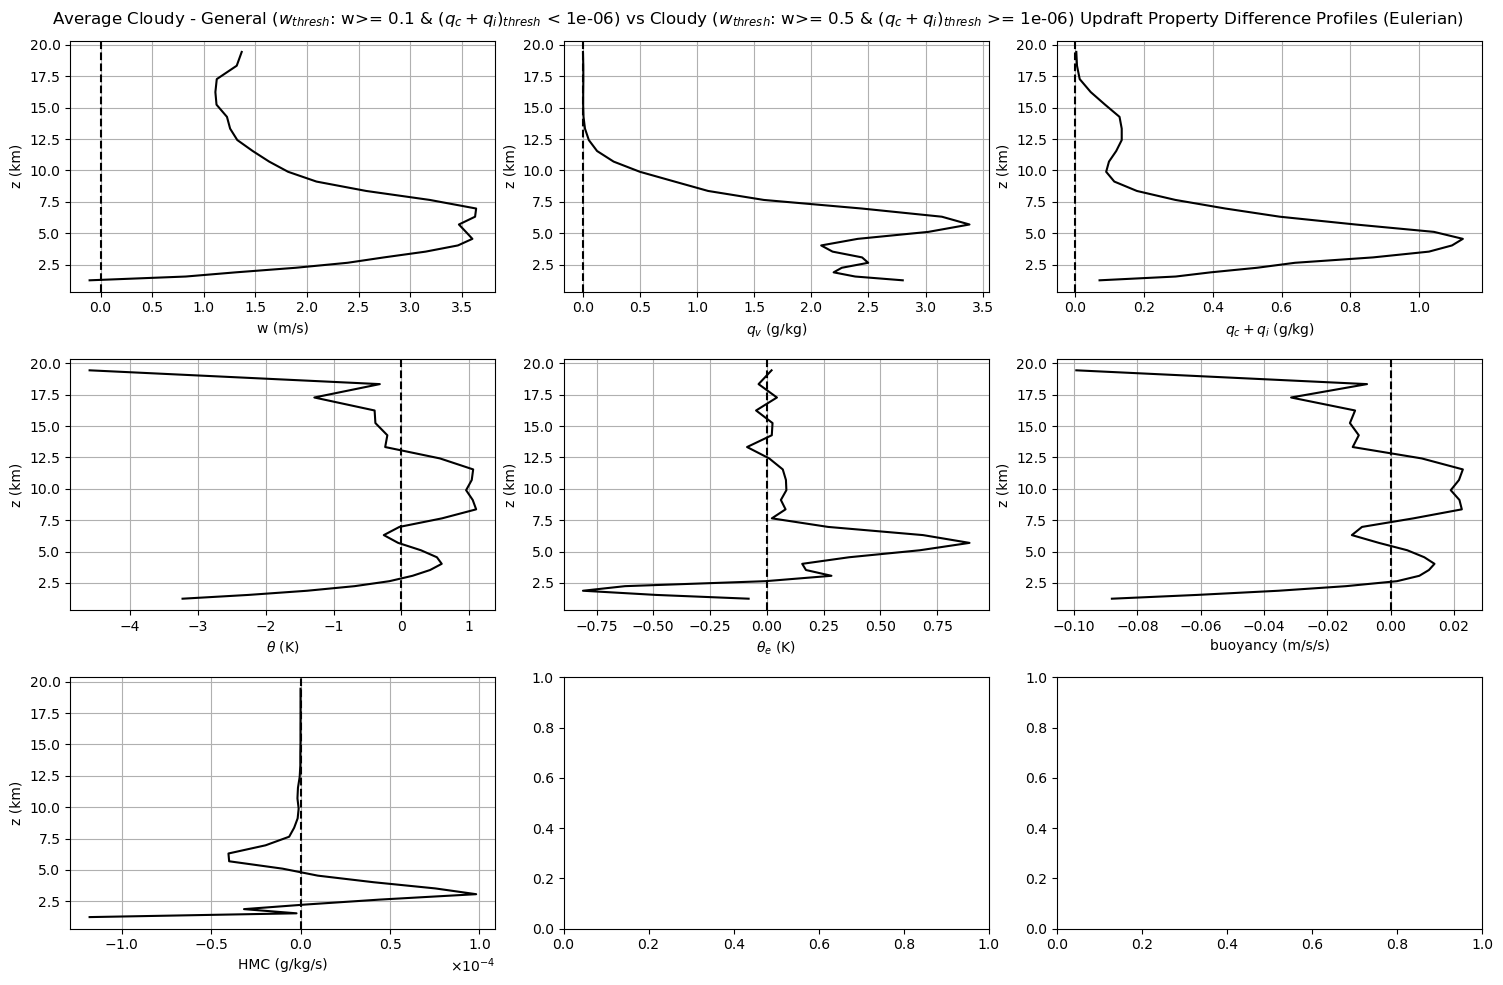

In [39]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

label=1

    
def get_data(type):
    if res=='1km':
        if type=='general':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_{res}_{Np_str}.h5'
            # input_file = dir+f'Project_Algorithms/plots/job_out/1km_general_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
        elif type=='cloudy':
            input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_{res}_{Np_str}.h5'
            # input_file = dir+f'Project_Algorithms/plots/job_out/1km_cloudy_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])
        globals()[f'{type}_profile_HMC'] = np.array(f['profile_HMC'])

    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(3, 3, figsize=(15, 10))
    fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles (Eulerian)")
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()

    #the plotting
    vars=['w','qv','qc','th','th_e','buoyancy','HMC']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        elif var=='qv':axis=ax2
        elif var=='qc':axis=ax3
        elif var=='th':axis=ax4
        elif var=='th_e':axis=ax5
        elif var=='buoyancy':axis=ax6
        elif var=='HMC':axis=ax7

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
       
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)
        
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        if axis==ax7:
            apply_scientific_notation([axis])

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
    plt.tight_layout()

# #MEAN CLOUD BASE
# for axis in axises:
#     axis.axhline(cloudbase,color='purple',linestyle='dashed')
    plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_updraft_profiles_diff_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) #save plot
diff_plotting() 

In [ ]:
#OTHER TESTING
######################################################

In [12]:
# #Loading in Equivalent Potential Temperature
# with h5py.File(dir+'theta_e_approx.h5', 'r') as f:
#     # Load the dataset by its name
#     theta_e_approx = f['theta_e_approx'][:]

# with h5py.File(dir+'theta_e.h5', 'r') as f:
#     # Load the dataset by its name
#     theta_e_data = f['theta_e'][:]

In [13]:
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     emptylike=True
    
# def final_profile(var,type):
#     global w_thresh
#     #thresholds
#     w_thresh=1
#     qcqi_thresh=1e-6

#     nt=len(data['time'])
        
#     #get qc and interpolated w 

#     # finds regions that match the threshold
#     if type=="general":
#         where_updraft=np.where((w_data>=w_thresh)) #uncomment for "general updraft"
#     elif type=='cloudy': 
#         where_updraft=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqi_thresh)) #uncomment for "cloudy updraft" 
    
#     #creates profile storage and adds z column    
#     zhs=data['zh'].values
#     profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#     profile_array[:,2]=zhs

#     #get incidies associated with threshold mask
#     t_ind, z_ind, y_ind, x_ind = where_updraft

#     #gets data associated with threshold mask
#     if var=='w':
#         masked_data=w_data[where_updraft]
#     if var=='qv':
#         masked_data=qv_data[where_updraft]
#     if var=='qc':
#         masked_data=qc_plus_qi[where_updraft] #data stored for qc is actually qc+qi
#     if var=='qi':
#         masked_data=qi_data[where_updraft]
#     if var=='th':
#         masked_data=th_data[where_updraft]
#     if var=='buoyancy':
#         masked_data=buoyancy_data[where_updraft]
#     if var=='theta_e':
#         masked_data=theta_e_data[where_updraft]
#     if var=='theta_e_test':
#         masked_data=theta_e_approx[where_updraft]
        
#     #converts qv and qc from kg/kg=>g/kg
#     if var in ['qv','qc','qi']:
#         masked_data*=1000

#     #bin masked values by z level
#     for (kh,value) in zip(z_ind,masked_data):
#         profile_array[kh,0]+=value #adds data to first column
#         profile_array[kh,1]+=1 #adds +1 counter to 2nd column
#     return profile_array

loading neccessary variables


In [14]:
# x1=final_profile('theta_e','general')
# x2=final_profile('theta_e','cloudy')

# x3=final_profile('theta_e_test','general')
# x4=final_profile('theta_e_test','cloudy')

In [8]:
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# x1_avg=averaged_profiles(x1)
# x2_avg=averaged_profiles(x2)

# plt.plot(x1_avg[:,0],x1_avg[:,1],label='general updraft',color='k')
# plt.plot(x2_avg[:,0],x2_avg[:,1],label='cloudy updraft',color='blue')
# plt.legend();

# x3_avg=averaged_profiles(x3)
# x4_avg=averaged_profiles(x4)


# plt.plot(x3_avg[:,0],x3_avg[:,1],label='general updraft - approx',color='k',linestyle='dashed')
# plt.plot(x4_avg[:,0],x4_avg[:,1],label='cloudy updraft - approx',color='b',linestyle='dashed')
# plt.legend();
# plt.title(r'$\theta_e$'+' in General vs Cloudy Updrafts')

# plt.xlim((330,380))

In [9]:
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# x1_avg=averaged_profiles(x1)
# x2_avg=averaged_profiles(x2)

# plt.plot(x1_avg[:,0],x1_avg[:,1],label='general updraft',color='k')
# plt.plot(x2_avg[:,0],x2_avg[:,1],label='cloudy updraft',color='blue')
# plt.legend();

# # x3_avg=averaged_profiles(x3)
# # x4_avg=averaged_profiles(x4)


# # plt.plot(x3_avg[:,0],x3_avg[:,1],label='general updraft - approx',color='k',linestyle='dashed')
# # plt.plot(x4_avg[:,0],x4_avg[:,1],label='cloudy updraft - approx',color='b',linestyle='dashed')
# # plt.legend();
# # plt.title(r'$\theta_e$'+' in General vs Cloudy Updrafts')

# plt.xlim((330,380))